# Exploratory Data Analysis (EDA): Google Trends, HCUP, & U.S. Census Bureau, & NEW temporal & spatial variables
**Author:** J. Casey Brookshier  
**Date:** August 12, 2026

## Objective

Prepare and explore a state-year Engineered dataset (with new spatial & temporal predictors) to evaluate whether suicide- and crisis-related Google Trends search activity is associated with future state-level inpatient psychiatric admissions.


## Workflow

**Summarize → Visualize → Assess Relationships → Identify Preprocessing Needs**


In [1]:

# imports & project paths

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ------------------------------------------------------------
# Repository structure
# ------------------------------------------------------------

# Expected notebook location:
# notebooks/processed/EDA_ENGINEERED_STATE_YEAR.ipynb

PROJECT_ROOT = Path.cwd().resolve().parents[1]

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR = (
    PROJECT_ROOT
    / "figures"
    / "EDA.eng"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("EDA figures:", FIGURES_DIR)



Unable to revert mtime: /Library/Fonts


Project root: /Users/caseybrookshier/Team-Rho-Capstone-Project
Processed data: /Users/caseybrookshier/Team-Rho-Capstone-Project/data/processed
EDA figures: /Users/caseybrookshier/Team-Rho-Capstone-Project/figures/EDA.eng


In [2]:
# define input file

INPUT_FILE = (
    PROCESSED_DIR
    / "team_rho_state_year_prediction_dataset.csv"
)

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Missing processed dataset: {INPUT_FILE}"
    )

df = pd.read_csv(INPUT_FILE)

print("Loaded:", INPUT_FILE)
print("Shape:", df.shape)

Loaded: /Users/caseybrookshier/Team-Rho-Capstone-Project/data/processed/team_rho_state_year_prediction_dataset.csv
Shape: (452, 13)


In [3]:

# Define the outcome, state grouping variable, time variable, Google Trends
# predictors, and engineered predictors.


TARGET = "admission_rate_per_100k"
GROUP = "State"
TIME = "Year"

SEARCH_TERMS = [
    "suicidal thoughts",
    "suicide hotline",
    "self harm",
    "mental health crisis",
    "suicide prevention",
    "crisis hotline",
    "psychiatric hospital",
    "depression help",
]

TREND_COLS = [
    f"{term}_lag1"
    for term in SEARCH_TERMS
    if f"{term}_lag1" in df.columns
]

print("Target:", TARGET)
print("Grouping variable:", GROUP)
print("Time variable:", TIME)
print("Google Trends predictors:", len(TREND_COLS))

Target: admission_rate_per_100k
Grouping variable: State
Time variable: Year
Google Trends predictors: 8


In [4]:
# data quality check

print("=" * 70)
print("EDA REPORT — ENGINEERED STATE-YEAR DATASET")
print("=" * 70)

print("Shape:", df.shape)
print("Observations:", len(df))
print("States:", df[GROUP].nunique())
print("Years:", df[TIME].min(), "-", df[TIME].max())

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate State-Year rows:",
    df.duplicated(
        [GROUP, TIME]
    ).sum()
)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

EDA REPORT — ENGINEERED STATE-YEAR DATASET
Shape: (452, 13)
Observations: 452
States: 46
Years: 2014 - 2023
Duplicate rows: 0
Duplicate State-Year rows: 0

Data types:


State                            str
Year                           int64
state_population             float64
mental_health_admissions     float64
admission_rate_per_100k      float64
suicidal thoughts_lag1       float64
suicide hotline_lag1         float64
self harm_lag1               float64
mental health crisis_lag1    float64
suicide prevention_lag1      float64
crisis hotline_lag1          float64
psychiatric hospital_lag1    float64
depression help_lag1         float64
dtype: object


Missing values:


State                         0
Year                          0
state_population              0
mental_health_admissions      0
admission_rate_per_100k       0
suicidal thoughts_lag1       10
suicide hotline_lag1          0
self harm_lag1                0
mental health crisis_lag1    19
suicide prevention_lag1       0
crisis hotline_lag1          19
psychiatric hospital_lag1    10
depression help_lag1          0
dtype: int64

In [5]:
# create a two-year lag of the admission rate within each state
#  lag represents historical state-level admission conditions and prevents
# the current outcome from being used as its own predictor
# ensure state-year ordering before temporal engineering

df = (
    df
    .sort_values(
        [GROUP, TIME]
    )
    .reset_index(drop=True)
)

# two-year historical admission-rate predictor

df["admission_rate_lag2"] = (
    df
    .groupby(GROUP)[TARGET]
    .shift(2)
)

print(
    "Created:",
    "admission_rate_lag2"
)

display(
    df[
        [
            GROUP,
            TIME,
            TARGET,
            "admission_rate_lag2"
        ]
    ].head(15)
)

Created: admission_rate_lag2


,State,Year,admission_rate_per_100k,admission_rate_lag2
0,Alaska,2015,297.929391,NaN
1,Alaska,2016,289.533044,NaN
2,Alaska,2017,303.650691,297.929391
3,Alaska,2018,319.023002,289.533044
4,Alaska,2019,333.968100,303.650691
5,Alaska,2020,348.761827,319.023002
6,Alaska,2021,381.165004,333.968100
7,Alaska,2022,395.279006,348.761827
8,Alaska,2023,374.325873,381.165004
9,Arizona,2014,223.530133,NaN


In [6]:
# spatial engineered predictor
# create a state-level spatial predictor representing the mean psychiatric
# admission rate among neighboring states during the previous year
# adjacency definition below uses contiguous U.S. state borders

# state adjacency mapping
# each state is mapped to states that share a land border

STATE_NEIGHBORS = {
    "Alabama": [
        "Florida", "Georgia", "Mississippi", "Tennessee"
    ],
    "Arizona": [
        "California", "Colorado", "Nevada",
        "New Mexico", "Utah"
    ],
    "Arkansas": [
        "Louisiana", "Mississippi", "Missouri",
        "Oklahoma", "Tennessee", "Texas"
    ],
    "California": [
        "Arizona", "Nevada", "Oregon"
    ],
    "Colorado": [
        "Arizona", "Kansas", "Nebraska",
        "New Mexico", "Oklahoma", "Utah", "Wyoming"
    ],
    "Connecticut": [
        "Massachusetts", "New York", "Rhode Island"
    ],
    "Delaware": [
        "Maryland", "New Jersey", "Pennsylvania"
    ],
    "Florida": [
        "Alabama", "Georgia"
    ],
    "Georgia": [
        "Alabama", "Florida", "North Carolina",
        "South Carolina", "Tennessee"
    ],
    "Idaho": [
        "Montana", "Nevada", "Oregon",
        "Utah", "Washington", "Wyoming"
    ],
    "Illinois": [
        "Indiana", "Iowa", "Kentucky",
        "Michigan", "Missouri", "Wisconsin"
    ],
    "Indiana": [
        "Illinois", "Kentucky", "Michigan", "Ohio"
    ],
    "Iowa": [
        "Illinois", "Minnesota", "Missouri",
        "Nebraska", "South Dakota", "Wisconsin"
    ],
    "Kansas": [
        "Colorado", "Missouri", "Nebraska",
        "Oklahoma"
    ],
    "Kentucky": [
        "Illinois", "Indiana", "Missouri",
        "Ohio", "Tennessee", "Virginia", "West Virginia"
    ],
    "Louisiana": [
        "Arkansas", "Mississippi", "Texas"
    ],
    "Maine": [
        "New Hampshire"
    ],
    "Maryland": [
        "Delaware", "Pennsylvania",
        "Virginia", "West Virginia"
    ],
    "Massachusetts": [
        "Connecticut", "New Hampshire",
        "New York", "Rhode Island", "Vermont"
    ],
    "Michigan": [
        "Illinois", "Indiana", "Ohio", "Wisconsin"
    ],
    "Minnesota": [
        "Iowa", "Michigan", "North Dakota",
        "South Dakota", "Wisconsin"
    ],
    "Mississippi": [
        "Alabama", "Arkansas", "Louisiana", "Tennessee"
    ],
    "Missouri": [
        "Arkansas", "Illinois", "Iowa",
        "Kansas", "Kentucky", "Nebraska",
        "Oklahoma", "Tennessee"
    ],
    "Montana": [
        "Idaho", "North Dakota",
        "South Dakota", "Wyoming"
    ],
    "Nebraska": [
        "Colorado", "Iowa", "Kansas",
        "Missouri", "South Dakota", "Wyoming"
    ],
    "Nevada": [
        "Arizona", "California", "Idaho", "Oregon", "Utah"
    ],
    "New Hampshire": [
        "Maine", "Massachusetts", "Vermont"
    ],
    "New Jersey": [
        "Delaware", "New York", "Pennsylvania"
    ],
    "New Mexico": [
        "Arizona", "Colorado", "Oklahoma", "Texas", "Utah"
    ],
    "New York": [
        "Connecticut", "Massachusetts",
        "New Jersey", "Pennsylvania", "Vermont"
    ],
    "North Carolina": [
        "Georgia", "South Carolina",
        "Tennessee", "Virginia"
    ],
    "North Dakota": [
        "Minnesota", "Montana", "South Dakota"
    ],
    "Ohio": [
        "Indiana", "Kentucky",
        "Michigan", "Pennsylvania",
        "West Virginia"
    ],
    "Oklahoma": [
        "Arkansas", "Colorado", "Kansas",
        "Missouri", "New Mexico", "Texas"
    ],
    "Oregon": [
        "California", "Idaho", "Nevada", "Washington"
    ],
    "Pennsylvania": [
        "Delaware", "Maryland", "New Jersey",
        "New York", "Ohio", "West Virginia"
    ],
    "Rhode Island": [
        "Connecticut", "Massachusetts"
    ],
    "South Carolina": [
        "Georgia", "North Carolina"
    ],
    "South Dakota": [
        "Iowa", "Minnesota", "Montana",
        "Nebraska", "North Dakota", "Wyoming"
    ],
    "Tennessee": [
        "Alabama", "Arkansas", "Georgia",
        "Kentucky", "Mississippi",
        "Missouri", "North Carolina", "Virginia"
    ],
    "Texas": [
        "Arkansas", "Louisiana",
        "New Mexico", "Oklahoma"
    ],
    "Utah": [
        "Arizona", "Colorado",
        "Idaho", "Nevada", "New Mexico", "Wyoming"
    ],
    "Vermont": [
        "Massachusetts", "New Hampshire", "New York"
    ],
    "Virginia": [
        "Kentucky", "Maryland",
        "North Carolina", "Tennessee",
        "West Virginia"
    ],
    "Washington": [
        "Idaho", "Oregon"
    ],
    "West Virginia": [
        "Kentucky", "Maryland",
        "Ohio", "Pennsylvania", "Virginia"
    ],
    "Wisconsin": [
        "Illinois", "Iowa", "Michigan", "Minnesota"
    ],
    "Wyoming": [
        "Colorado", "Idaho", "Montana",
        "Nebraska", "South Dakota", "Utah"
    ],
}

In [7]:

# build state-neighbor pairs

neighbor_pairs = []

for state, neighbors in STATE_NEIGHBORS.items():

    for neighbor in neighbors:

        neighbor_pairs.append(
            {
                "State": state,
                "Neighbor": neighbor
            }
        )

neighbor_pairs = pd.DataFrame(
    neighbor_pairs
)

print(
    "State-neighbor pairs:",
    len(neighbor_pairs)
)

display(
    neighbor_pairs.head(10)
)

State-neighbor pairs: 217


,State,Neighbor
0,Alabama,Florida
1,Alabama,Georgia
2,Alabama,Mississippi
3,Alabama,Tennessee
4,Arizona,California
5,Arizona,Colorado
6,Arizona,Nevada
7,Arizona,New Mexico
8,Arizona,Utah
9,Arkansas,Louisiana


In [8]:
# calculate previous-year neighboring admission rates

spatial = (
    df[
        [
            GROUP,
            TIME
        ]
    ]
    .drop_duplicates()
    .merge(
        neighbor_pairs,
        left_on=GROUP,
        right_on="State",
        how="left"
    )
)

spatial["neighbor_year"] = (
    spatial[TIME] - 1
)

neighbor_rates = (
    df[
        [
            GROUP,
            TIME,
            TARGET
        ]
    ]
    .rename(
        columns={
            GROUP: "Neighbor",
            TIME: "neighbor_year",
            TARGET: "neighbor_rate"
        }
    )
)

spatial = spatial.merge(
    neighbor_rates,
    on=[
        "Neighbor",
        "neighbor_year"
    ],
    how="left"
)

spatial_summary = (
    spatial
    .groupby(
        [GROUP, TIME],
        as_index=False
    )["neighbor_rate"]
    .mean()
    .rename(
        columns={
            "neighbor_rate":
            "neighbor_admission_rate_lag1"
        }
    )
)

df = df.merge(
    spatial_summary,
    on=[
        GROUP,
        TIME
    ],
    how="left",
    validate="one_to_one"
)

print(
    "Created:",
    "neighbor_admission_rate_lag1"
)

display(
    df[
        [
            GROUP,
            TIME,
            TARGET,
            "neighbor_admission_rate_lag1"
        ]
    ].head(15)
)

Created: neighbor_admission_rate_lag1


,State,Year,admission_rate_per_100k,neighbor_admission_rate_lag1
0,Alaska,2015,297.929391,NaN
1,Alaska,2016,289.533044,NaN
2,Alaska,2017,303.650691,NaN
3,Alaska,2018,319.023002,NaN
4,Alaska,2019,333.968100,NaN
5,Alaska,2020,348.761827,NaN
6,Alaska,2021,381.165004,NaN
7,Alaska,2022,395.279006,NaN
8,Alaska,2023,374.325873,NaN
9,Arizona,2014,223.530133,NaN


In [9]:
# define EDA variable groups

ENGINEERED_COLS = [
    c
    for c in [
        "admission_rate_lag2",
        "neighbor_admission_rate_lag1",
    ]
    if c in df.columns
]

PREDICTOR_COLS = list(
    dict.fromkeys(
        TREND_COLS
        + ENGINEERED_COLS
    )
)

EDA_NUMERIC = list(
    dict.fromkeys(
        c
        for c in (
            [
                "state_population",
                TARGET,
            ]
            + PREDICTOR_COLS
        )
        if c in df.columns
    )
)

print("Google Trends predictors:")

for col in TREND_COLS:
    print(" -", col)

print("\nEngineered predictors:")

for col in ENGINEERED_COLS:
    print(" -", col)

print(
    "\nTotal predictors:",
    len(PREDICTOR_COLS)
)

Google Trends predictors:
 - suicidal thoughts_lag1
 - suicide hotline_lag1
 - self harm_lag1
 - mental health crisis_lag1
 - suicide prevention_lag1
 - crisis hotline_lag1
 - psychiatric hospital_lag1
 - depression help_lag1

Engineered predictors:
 - admission_rate_lag2
 - neighbor_admission_rate_lag1

Total predictors: 10


In [10]:
# data quality check after engineering

print("=" * 70)
print("EDA REPORT — ENGINEERED STATE-YEAR DATASET")
print("=" * 70)

print("Shape:", df.shape)
print("Observations:", len(df))
print("States:", df[GROUP].nunique())
print("Years:", df[TIME].min(), "-", df[TIME].max())
print("Google Trends predictors:", len(TREND_COLS))
print("Engineered predictors:", len(ENGINEERED_COLS))
print("Total predictors:", len(PREDICTOR_COLS))

print(
    "\nDuplicate State-Year rows:",
    df.duplicated(
        [GROUP, TIME]
    ).sum()
)

print("\nMissing values:")

display(
    df[EDA_NUMERIC]
    .isna()
    .sum()
)

EDA REPORT — ENGINEERED STATE-YEAR DATASET
Shape: (452, 15)
Observations: 452
States: 46
Years: 2014 - 2023
Google Trends predictors: 8
Engineered predictors: 2
Total predictors: 10

Duplicate State-Year rows: 0

Missing values:


state_population                 0
admission_rate_per_100k          0
suicidal thoughts_lag1          10
suicide hotline_lag1             0
self harm_lag1                   0
mental health crisis_lag1       19
suicide prevention_lag1          0
crisis hotline_lag1             19
psychiatric hospital_lag1       10
depression help_lag1             0
admission_rate_lag2             92
neighbor_admission_rate_lag1    71
dtype: int64

In [11]:

# descriptive statistics table 1

numeric = df[
    EDA_NUMERIC
].copy()

desc = numeric.describe().T

table1 = pd.DataFrame({
    "Variable": desc.index,
    "Count": desc["count"].values,
    "Mean": numeric.mean().values,
    "Median": numeric.median().values,
    "Std Dev": numeric.std().values,
    "Minimum": numeric.min().values,
    "Q1": numeric.quantile(0.25).values,
    "Q3": numeric.quantile(0.75).values,
    "Maximum": numeric.max().values,
    "Skew": numeric.skew().values,
    "Kurtosis": numeric.kurtosis().values,
})

table1 = table1.round(2)

print(
    "TABLE 1 — DESCRIPTIVE STATISTICS"
)

display(table1)

table1.to_csv(
    FIGURES_DIR
    / "Table_1_Descriptive_Statistics.csv",
    index=False
)

TABLE 1 — DESCRIPTIVE STATISTICS


,Variable,Count,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum,Skew,Kurtosis
0,state_population,452.0,6856513.13,4995066.50,7384389.65,579054.00,1957910.75,8565122.25,39437610.00,2.44,6.86
1,admission_rate_per_100k,452.0,401.80,395.85,148.15,110.11,285.13,497.96,826.91,0.55,-0.05
2,suicidal thoughts_lag1,442.0,39.27,44.33,24.19,0.00,17.77,56.77,88.42,-0.35,-1.02
3,suicide hotline_lag1,452.0,36.42,39.25,19.36,0.00,23.67,52.29,71.00,-0.36,-0.94
4,self harm_lag1,452.0,43.65,45.42,21.65,0.00,32.06,57.48,90.75,-0.30,-0.53
5,mental health crisis_lag1,433.0,17.34,8.33,20.91,0.00,0.00,29.67,87.33,1.13,0.34
6,suicide prevention_lag1,452.0,24.99,27.33,10.36,0.00,18.48,32.92,50.67,-0.56,-0.38
7,crisis hotline_lag1,433.0,24.98,15.75,24.55,0.00,0.00,48.25,82.17,0.48,-1.26
8,psychiatric hospital_lag1,442.0,45.59,56.00,28.21,0.00,16.94,69.75,89.50,-0.44,-1.32
9,depression help_lag1,452.0,50.85,58.12,22.38,0.00,41.29,67.60,81.83,-0.98,-0.21


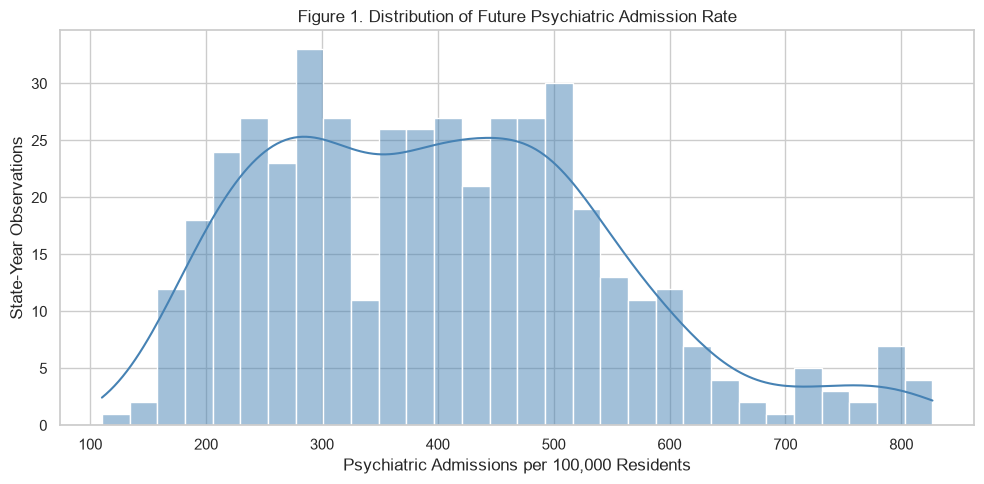

In [12]:
# figure 1 — target distribution

plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    data=df,
    x=TARGET,
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title(
    "Figure 1. Distribution of Future Psychiatric Admission Rate"
)

plt.xlabel(
    "Psychiatric Admissions per 100,000 Residents"
)

plt.ylabel(
    "State-Year Observations"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "Figure_1_Target_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

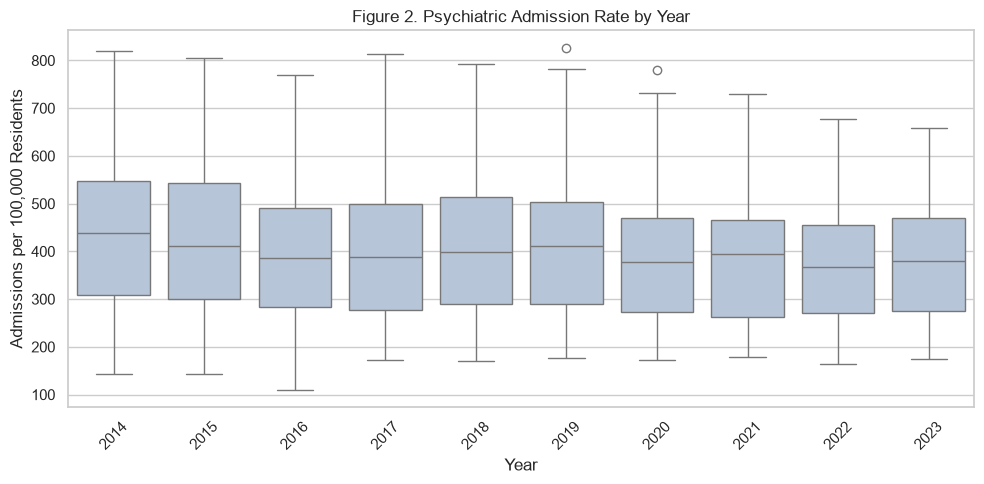

In [13]:
# figure 2 — outcome by year

plt.figure(
    figsize=(10, 5)
)

sns.boxplot(
    data=df,
    x=TIME,
    y=TARGET,
    color="lightsteelblue"
)

plt.title(
    "Figure 2. Psychiatric Admission Rate by Year"
)

plt.xlabel("Year")

plt.ylabel(
    "Admissions per 100,000 Residents"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "Figure_2_Outcome_by_Year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

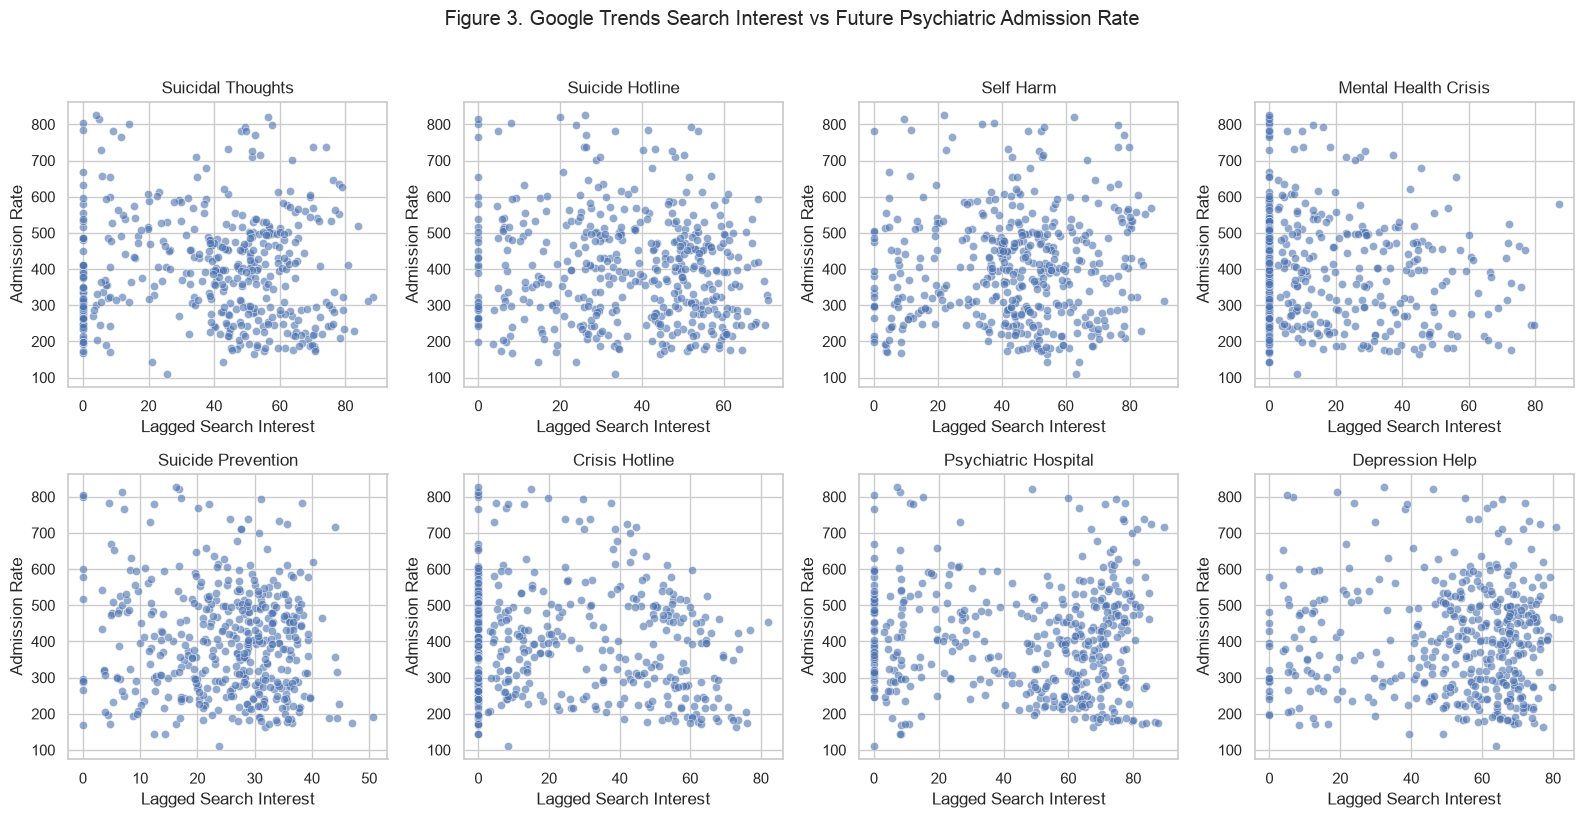

In [14]:
# %%
# Figure 3 — Google Trends predictors vs future outcome

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

axes = np.asarray(
    axes
).flatten()

for ax, col in zip(
    axes,
    TREND_COLS
):

    sns.scatterplot(
        data=df,
        x=col,
        y=TARGET,
        ax=ax,
        alpha=0.60,
        s=35
    )

    ax.set_title(
        col
        .replace("_lag1", "")
        .title()
    )

    ax.set_xlabel(
        "Lagged Search Interest"
    )

    ax.set_ylabel(
        "Admission Rate"
    )

for ax in axes[
    len(TREND_COLS):
]:
    ax.remove()

fig.suptitle(
    "Figure 3. Google Trends Search Interest vs Future Psychiatric Admission Rate",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "Figure_3_Google_Trends_vs_Outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

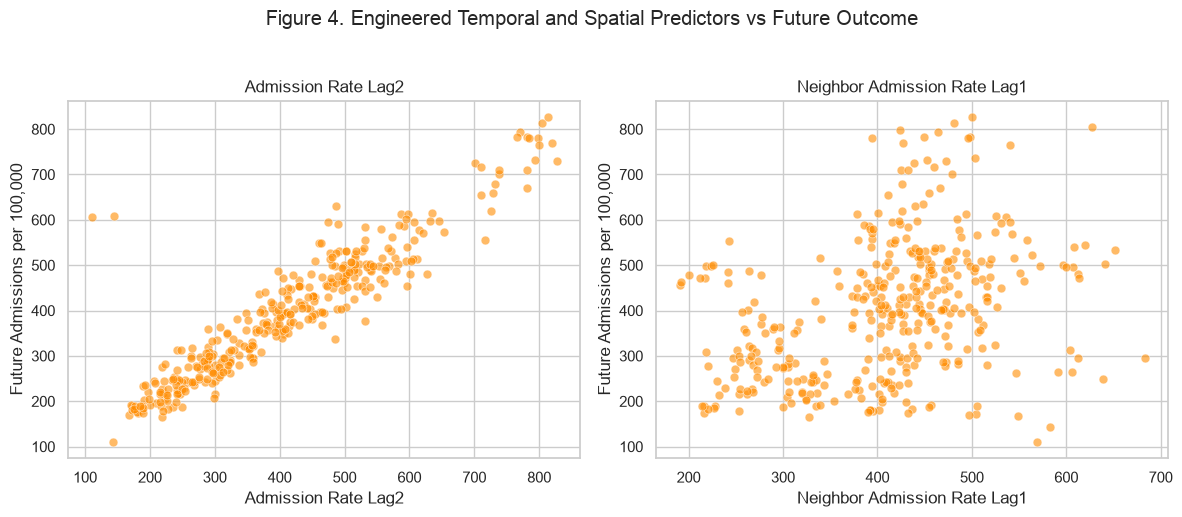

In [15]:
# figure 4 — temporal and spatial engineered predictors

if ENGINEERED_COLS:

    fig, axes = plt.subplots(
        1,
        len(ENGINEERED_COLS),
        figsize=(12, 5)
    )

    if len(ENGINEERED_COLS) == 1:
        axes = [axes]

    for ax, col in zip(
        axes,
        ENGINEERED_COLS
    ):

        sns.scatterplot(
            data=df,
            x=col,
            y=TARGET,
            ax=ax,
            alpha=0.60,
            s=40,
            color="darkorange"
        )

        ax.set_title(
            col
            .replace("_", " ")
            .title()
        )

        ax.set_xlabel(
            col
            .replace("_", " ")
            .title()
        )

        ax.set_ylabel(
            "Future Admissions per 100,000"
        )

    fig.suptitle(
        "Figure 4. Engineered Temporal and Spatial Predictors vs Future Outcome",
        y=1.03
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / "Figure_4_Engineered_Predictors.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

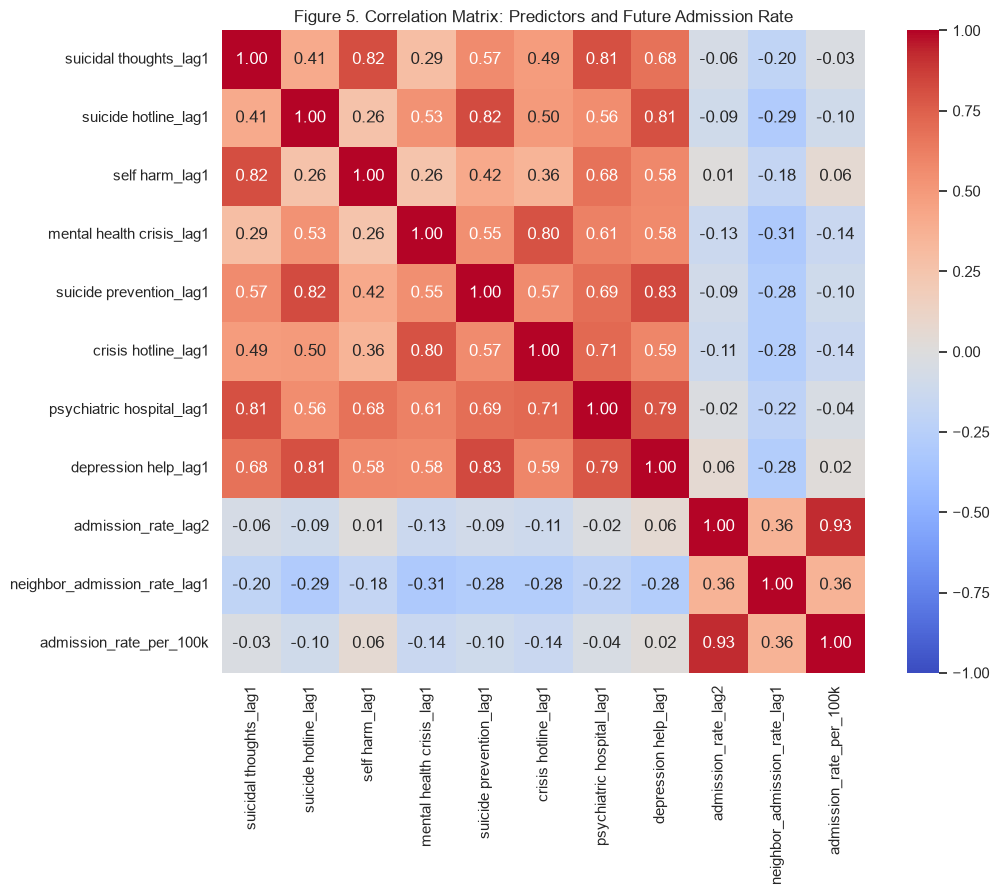

In [16]:
# correlation matrix

CORR_COLS = list(
    dict.fromkeys(
        PREDICTOR_COLS
        + [TARGET]
    )
)

corr = df[
    CORR_COLS
].corr()

plt.figure(
    figsize=(11, 9)
)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Figure 5. Correlation Matrix: Predictors and Future Admission Rate"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "Figure_5_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [17]:
# table2 - predictor correlations with future admission

outcome_correlations = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values()
    .rename("Correlation")
    .reset_index()
    .rename(
        columns={
            "index": "Predictor"
        }
    )
)

outcome_correlations[
    "Absolute_Correlation"
] = (
    outcome_correlations[
        "Correlation"
    ].abs()
)

table2 = (
    outcome_correlations
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .drop(
        columns="Absolute_Correlation"
    )
    .round(3)
)

print(
    "TABLE 2 — PREDICTOR CORRELATIONS "
    "WITH FUTURE ADMISSION RATE"
)

display(table2)

table2.to_csv(
    FIGURES_DIR
    / "Table_2_Outcome_Correlations.csv",
    index=False
)

TABLE 2 — PREDICTOR CORRELATIONS WITH FUTURE ADMISSION RATE


,Predictor,Correlation
9,admission_rate_lag2,0.928
8,neighbor_admission_rate_lag1,0.360
0,mental health crisis_lag1,-0.145
1,crisis hotline_lag1,-0.141
2,suicide prevention_lag1,-0.103
3,suicide hotline_lag1,-0.100
7,self harm_lag1,0.056
4,psychiatric hospital_lag1,-0.041
5,suicidal thoughts_lag1,-0.031
6,depression help_lag1,0.022


In [18]:
# preprocessing assessment
# assess missingness and temporal/spatial structure before model fitting
# lagged predictors naturally produce missing values at the beginning of
# state-level time series, spatial predictors can also be missing when a
# state's neighbors lack the required prior-year observation

missing_summary = (
    df[PREDICTOR_COLS]
    .isna()
    .sum()
    .rename("Missing")
    .to_frame()
)

missing_summary["Missing_Percent"] = (
    missing_summary["Missing"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Percent",
        ascending=False
    )
    .round(2)
)

print(
    "MISSING PREDICTOR SUMMARY"
)

display(
    missing_summary
)


MISSING PREDICTOR SUMMARY


,Missing,Missing_Percent
admission_rate_lag2,92,20.35
neighbor_admission_rate_lag1,71,15.71
mental health crisis_lag1,19,4.20
crisis hotline_lag1,19,4.20
suicidal thoughts_lag1,10,2.21
psychiatric hospital_lag1,10,2.21
suicide hotline_lag1,0,0.00
self harm_lag1,0,0.00
suicide prevention_lag1,0,0.00
depression help_lag1,0,0.00


In [19]:

# state-year completeness

state_year_check = (
    df
    .groupby(GROUP)[TIME]
    .agg(
        First_Year="min",
        Last_Year="max",
        Observations="count"
    )
)

state_year_check[
    "Expected_Observations"
] = (
    state_year_check["Last_Year"]
    - state_year_check["First_Year"]
    + 1
)

state_year_check[
    "Missing_State_Years"
] = (
    state_year_check[
        "Expected_Observations"
    ]
    - state_year_check[
        "Observations"
    ]
)

print(
    "STATE-YEAR COMPLETENESS"
)

display(
    state_year_check
)

STATE-YEAR COMPLETENESS


,First_Year,Last_Year,Observations,Expected_Observations,Missing_State_Years
State,,,,,
Alaska,2015,2023,9,9,0
Arizona,2014,2023,10,10,0
Arkansas,2014,2023,10,10,0
California,2014,2022,9,9,0
Colorado,2014,2023,10,10,0
Delaware,2016,2023,8,8,0
Florida,2014,2023,10,10,0
Georgia,2014,2023,10,10,0
Hawaii,2014,2023,10,10,0


In [20]:
# identify predictors requiring preprocessing attention

preprocessing_flags = pd.DataFrame(
    {
        "Predictor": PREDICTOR_COLS,
        "Missing_Count": [
            df[col].isna().sum()
            for col in PREDICTOR_COLS
        ],
        "Missing_Percent": [
            round(
                df[col].isna().mean() * 100,
                2
            )
            for col in PREDICTOR_COLS
        ],
    }
)

preprocessing_flags[
    "Requires_Attention"
] = (
    preprocessing_flags[
        "Missing_Count"
    ] > 0
)

display(
    preprocessing_flags
)

preprocessing_flags.to_csv(
    FIGURES_DIR
    / "Table_3_Preprocessing_Missingness.csv",
    index=False
)

,Predictor,Missing_Count,Missing_Percent,Requires_Attention
0,suicidal thoughts_lag1,10,2.21,True
1,suicide hotline_lag1,0,0.00,False
2,self harm_lag1,0,0.00,False
3,mental health crisis_lag1,19,4.20,True
4,suicide prevention_lag1,0,0.00,False
5,crisis hotline_lag1,19,4.20,True
6,psychiatric hospital_lag1,10,2.21,True
7,depression help_lag1,0,0.00,False
8,admission_rate_lag2,92,20.35,True
9,neighbor_admission_rate_lag1,71,15.71,True


In [21]:
# EDA summary

print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print(
    f"The engineered dataset contains "
    f"{len(df)} state-year observations "
    f"across {df[GROUP].nunique()} states "
    f"from {df[TIME].min()} through "
    f"{df[TIME].max()}."
)

print(
    f"The outcome has a mean of "
    f"{df[TARGET].mean():.2f} and a "
    f"standard deviation of "
    f"{df[TARGET].std():.2f} admissions "
    f"per 100,000 residents."
)

print(
    f"The dataset contains "
    f"{len(TREND_COLS)} lagged Google Trends "
    f"predictors and "
    f"{len(ENGINEERED_COLS)} engineered "
    f"temporal/spatial predictors."
)

print(
    f"There are "
    f"{df.duplicated().sum()} duplicate rows."
)

print("\nMissing predictor values:")

display(
    df[PREDICTOR_COLS].isna().sum()
)

print(
    "\nPredictor correlations with outcome:"
)

display(
    table2
)

print(
    "\nEDA outputs saved to:"
)

print(
    FIGURES_DIR
)

print("\nEDA COMPLETE")

EDA SUMMARY
The engineered dataset contains 452 state-year observations across 46 states from 2014 through 2023.
The outcome has a mean of 401.80 and a standard deviation of 148.15 admissions per 100,000 residents.
The dataset contains 8 lagged Google Trends predictors and 2 engineered temporal/spatial predictors.
There are 0 duplicate rows.

Missing predictor values:


suicidal thoughts_lag1          10
suicide hotline_lag1             0
self harm_lag1                   0
mental health crisis_lag1       19
suicide prevention_lag1          0
crisis hotline_lag1             19
psychiatric hospital_lag1       10
depression help_lag1             0
admission_rate_lag2             92
neighbor_admission_rate_lag1    71
dtype: int64


Predictor correlations with outcome:


,Predictor,Correlation
9,admission_rate_lag2,0.928
8,neighbor_admission_rate_lag1,0.360
0,mental health crisis_lag1,-0.145
1,crisis hotline_lag1,-0.141
2,suicide prevention_lag1,-0.103
3,suicide hotline_lag1,-0.100
7,self harm_lag1,0.056
4,psychiatric hospital_lag1,-0.041
5,suicidal thoughts_lag1,-0.031
6,depression help_lag1,0.022



EDA outputs saved to:
/Users/caseybrookshier/Team-Rho-Capstone-Project/figures/EDA.eng

EDA COMPLETE


In [22]:
# final validation

assert df.duplicated(
    [GROUP, TIME]
).sum() == 0

assert df[TARGET].notna().all()

assert df["state_population"].notna().all()

assert (
    df["state_population"] > 0
).all()

assert (
    df[TARGET] >= 0
).all()

print("=" * 70)
print("EDA VALIDATION PASSED")
print("=" * 70)

print(
    f"Rows: {len(df):,}"
)

print(
    f"Columns: {len(df.columns)}"
)

print(
    f"States: {df[GROUP].nunique()}"
)

print(
    f"Years: {df[TIME].min()}-{df[TIME].max()}"
)

print(
    "Duplicate State-Year rows:",
    df.duplicated(
        [GROUP, TIME]
    ).sum()
)

print(
    "Missing outcome values:",
    df[TARGET].isna().sum()
)

print(
    "Missing population values:",
    df["state_population"].isna().sum()
)

print(
    "\nGenerated EDA files:"
)

for file in sorted(
    FIGURES_DIR.iterdir()
):
    print(
        " -",
        file.name
    )

print(
    "\nEDA COMPLETE"
)

EDA VALIDATION PASSED
Rows: 452
Columns: 15
States: 46
Years: 2014-2023
Duplicate State-Year rows: 0
Missing outcome values: 0
Missing population values: 0

Generated EDA files:
 - Figure_1_Target_Distribution.png
 - Figure_2_Outcome_by_Year.png
 - Figure_3_Google_Trends_vs_Outcome.png
 - Figure_4_Engineered_Predictors.png
 - Figure_5_Correlation_Heatmap.png
 - Table_1_Descriptive_Statistics.csv
 - Table_2_Outcome_Correlations.csv
 - Table_3_Preprocessing_Missingness.csv

EDA COMPLETE
